## Metric definitions and relevance to wood defect segmentation

Based on: Taha & Hanbury (2015) - Metrics for evaluating 3D medical
image segmentation: analysis, selection, and tool (PMC4533825)

---

### IoU - Intersection over Union
**Formula:** TP / (TP + FP + FN)

The ratio of correctly predicted defect pixels to the total number
of pixels predicted or annotated as defect. A prediction that exactly
matches the ground truth gives IoU = 1.0. IoU is the strictest
overlap metric. It penalises both missing pixels (FN) and predicting
too much (FP) simultaneously.

**Limitation:** Sensitive to class imbalance. A crack occupying
0.01% of pixels can drag down mean IoU dramatically even when
all other classes are detected perfectly.

---

### Dice - Dice Similarity Coefficient (= F1 Score)
**Formula:** 2×TP / (2×TP + FP + FN)

Mathematically identical to F1 score. Dice weights the overlap more
generously than IoU - it is always higher than IoU for the same
prediction. The relationship is: Dice = 2×IoU / (1 + IoU). 
It is less sensitive to very small defect instances than IoU, 
so it gives a more stable number whencrack annotations vary 
widely in size across images.

**Limitation:** Same as IoU - does not distinguish between a model
that over-detects (high FP) vs one that under-detects (high FN).
Recall and Precision are needed to separate these cases.

---

### Recall (Sensitivity, True Positive Rate)
**Formula:** TP / (TP + FN)

The fraction of annotated defect pixels that the model successfully
detected. Recall = 1.0 means every annotated pixel was found.
Recall = 0.0 means nothing was found. Recall does not care about
false positives - a model that predicts everything as defect gets
perfect recall. Missing a crack (FN) in structural
timber is more dangerous than a false alarm (FP). A high-recall
model finds all defects but may flag clean wood areas unnecessarily.

**Limitation:** Must always be reported alongside Precision.
Recall alone is trivially maximised by predicting every pixel as
defect.

---

### Precision (Positive Predictive Value)
**Formula:** TP / (TP + FP)

The fraction of predicted defect pixels that are genuinely defects.
Precision = 1.0 means every prediction is correct. Precision = 0.0
means every prediction is a false alarm. Precision measures how 
trustworthy the model'sdefect alerts are. Low precision means the 
model raises many falsealarms on clean wood - costly in an industrial 
inspection context because operators must verify every flagged region.

**Limitation:** Like recall, must be reported with its counterpart.
Precision alone is trivially maximised by making very few, very
confident predictions.

---

### Volumetric Similarity (VS)
**Formula:** 1 − |pred_pixels − gt_pixels| / (pred_pixels + gt_pixels)

Measures whether the predicted defect region is the right size,
regardless of whether it is in the right place. VS = 1.0 means the
prediction and ground truth have identical pixel counts. VS = 0.0
means one is empty while the other is not. VS directly quantifies 
the crack thinningproblem identified in visualisations. A model that 
finds the crackcentreline but predicts it as 1px wide when the annotation
is 3px wide will have VS well below 1.0 even if recall is high.

**Limitation:** VS can be 1.0 even when the prediction is in
completely the wrong location, for example a prediction of exactly the right
number of pixels but all in the wrong place gives perfect VS.
It must be read alongside IoU and the boundary metrics.

---

### Hausdorff Distance (HD)
**Formula:** max(
    max over all pred pixels  of  min distance to any GT pixel,
    max over all GT pixels    of  min distance to any pred pixel
)

The maximum over all predicted pixels of the distance to the nearest
ground truth pixel, and vice versa - whichever direction is worse.
HD measures the single worst-case boundary error in the entire image.
Units are pixels.HD captures crack tip extension errors. A model
that correctly predicts the full main crack channel but stops 15px
short of the annotated tip will have HD = 15. A lower HD
means the model extends crack predictions closer to their annotated
endpoints.

**Limitation:** HD is highly sensitive to outliers - a single
isolated false positive pixel far from any GT pixel will dominate
the HD value.

---

### ASSD - Average Symmetric Surface Distance
**Formula:** (mean over all pred pixels of min distance to any GT pixel + mean over all GT pixels   of min distance to any pred pixel) / 2

The average over all predicted boundary pixels of the distance to
the nearest ground truth boundary pixel, averaged in both directions.
Units are pixels. Unlike HD, ASSD is not dominated by outliers. Rather
it reflects typical boundary accuracy rather than worst-case. 
ASSD is the most informative boundary metric
for cracks. Low ASSD on kmen9
confirmed that wherever crack pixels are predicted they are
geometrically very close to the annotation - the problem is not
that predictions are in the wrong place but that there are not
enough of them (captured by recall) and they are too thin (captured
by VS).

**Limitation:** Like VS, ASSD can appear low when a model under-
predicts - if only the most certain crack pixels are predicted and
they happen to be on the main channel, ASSD will be low even though
recall is poor. Reading ASSD alongside recall prevents this
misinterpretation.

In [1]:
import sys, os, random
import numpy as np
import pandas as pd
from collections import defaultdict
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from tqdm import tqdm
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

sys.path.insert(0, os.path.abspath(".."))
from wood_utils import *
plt.rcParams.update(PLOT_RCPARAMS)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CACHE_DIR = "./eval_cache"
OUT_DIR   = "./outputs/evaluation"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR,   exist_ok=True)


Device: cuda


In [2]:
# MODELS and COMMON_TEST_LOGS are imported from wood_utils.config
print("Models registered:")
for name, cfg in MODELS.items():
    print(f"  {name}: {cfg['type']}  mrf={cfg['mrf']}  path={cfg['path']}")
print(f"\nCommon test logs: {COMMON_TEST_LOGS}")


Models registered:
  DilatedCNN+MRF log-split: dilated  mrf=True  path=../logs/20_trees/checkpoints/best.pt
  DilatedCNN+MRF random-split: dilated  mrf=True  path=../logs/20_trees_random-split/checkpoints/best.pt
  UNet++ log-split: unetpp  mrf=False  path=../logs/20_trees_UNET++/checkpoints/best.pt
  UNet++ random-split: unetpp  mrf=False  path=../logs/20_trees_UNET++_random-split/checkpoints/best.pt

Common test logs: ['Dub 9', 'kmen9']


In [3]:
all_pairs  = build_pairs(IMAGES_ROOT, GT_ROOT)
log_pairs  = group_by_log(all_pairs, IMAGES_ROOT)
all_logs   = sorted(log_pairs.keys())
test_pairs = [p for lg in COMMON_TEST_LOGS for p in log_pairs[lg]]
print(f"Total pairs : {len(all_pairs)}")
print(f"All logs    : {all_logs}")
print(f"Common test : {len(test_pairs)} pairs from {COMMON_TEST_LOGS}")


Total pairs : 1347
All logs    : ['Dub 1', 'Dub 10', 'Dub 2', 'Dub 3', 'Dub 4', 'Dub 5', 'Dub 6', 'Dub 7', 'Dub 8', 'Dub 9', 'kmen1', 'kmen10', 'kmen2', 'kmen3', 'kmen4', 'kmen5', 'kmen6', 'kmen7', 'kmen8', 'kmen9']
Common test : 128 pairs from ['Dub 9', 'kmen9']


In [4]:
cached_test = build_cache(test_pairs, os.path.join(CACHE_DIR, "test"), force=False)
print(f"Test cache ready: {len(cached_test)} pairs")


Caching → test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 21326.40it/s]

  Cache OK — img: (1, 256, 256) float32 | mask: (256, 256) unique: [0, 1, 2, 4]
Test cache ready: 128 pairs


In [5]:
# DilatedSegCNN, build_unetpp, load_checkpoint - all from wood_utils.models
# Quick sanity: count params for each architecture
_d = DilatedSegCNN()
_u = build_unetpp()
print(f"DilatedSegCNN params : {sum(p.numel() for p in _d.parameters()):,}")
print(f"UNet++ params        : {sum(p.numel() for p in _u.parameters()):,}")
del _d, _u


  UNet++ encoder: 216/216 ImageNet weights loaded
DilatedSegCNN params : 5,377,861
UNet++ params        : 26,072,917


In [6]:
# mrf_gibbs_sampling_2d imported from wood_utils.mrf
# Alias for backward compatibility with cells below
mrf_gibbs_sampling = mrf_gibbs_sampling_2d


In [7]:
# compute_image_metrics, compute_boundary_metrics_2d - from wood_utils.metrics
compute_boundary_metrics = compute_boundary_metrics_2d
METRICS = ["iou", "dice", "recall", "precision", "vs", "hd", "assd"]


In [8]:
# Helper functions used by the visual comparison cell
def predict_single(model, img_npy, use_mrf=False, beta=0.8):
    img = torch.tensor(np.load(img_npy)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(img), dim=1).squeeze(0)
    if use_mrf:
        return mrf_gibbs_sampling(probs, beta=beta).cpu().numpy()
    return torch.argmax(probs, dim=0).cpu().numpy()

def colorise_mask(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.float32)
    for c, hx in CLASS_COLORS_HEX.items():
        rgb[mask_np == c] = hex_to_rgb(hx)
    return rgb

def get_slice_idx(log_id, slice_number):
    candidates = [i for i in range(len(test_pairs))
                  if get_log_id(test_pairs[i][0]) == log_id]
    if not candidates:
        return None
    if 'kmen' in log_id.lower():
        candidates.sort(key=lambda i: int((np.load(cached_test[i][1]) == 4).sum()),
                        reverse=True)
    else:
        candidates.sort(key=lambda i: int((np.load(cached_test[i][1]) == 3).sum()),
                        reverse=True)
    if slice_number >= len(candidates):
        return candidates[-1]
    return candidates[slice_number]


In [9]:
from torch.utils.data import DataLoader, TensorDataset
 
EVAL_BATCH_SIZE = 32
METRICS = ["iou", "dice", "recall", "precision", "vs", "hd", "assd"]
 
def make_eval_loader(cached_pairs, batch_size=EVAL_BATCH_SIZE):
    imgs  = np.stack([np.load(p[0]) for p in cached_pairs])
    masks = np.stack([np.load(p[1]) for p in cached_pairs])
    ds    = TensorDataset(
        torch.tensor(imgs,  dtype=torch.float32),
        torch.tensor(masks, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
 
 
all_dfs = {}
 
for model_name, model_cfg in MODELS.items():
    if not os.path.exists(model_cfg["path"]):
        print(f"Skipping '{model_name}' - not found: {model_cfg['path']}")
        continue
 
    print(f"\n{'-'*60}")
    print(f" Evaluating: {model_name}")
    print(f"{'-'*60}")
 
    model   = load_checkpoint(model_cfg)
    use_mrf = model_cfg["mrf"]
    beta    = model_cfg.get("mrf_beta", 0.8)
    loader  = make_eval_loader(cached_test)
 
    # -- step 1: batched GPU inference ------------------------
    all_preds, all_gts = [], []
    with torch.no_grad():
        for imgs_b, masks_b in tqdm(loader, desc="  Inference"):
            probs = F.softmax(model(imgs_b.to(device)), dim=1)
            if use_mrf:
                preds_b = torch.stack([
                    mrf_gibbs_sampling(probs[b], beta=beta)
                    for b in range(len(probs))
                ]).cpu().numpy()
            else:
                preds_b = torch.argmax(probs, dim=1).cpu().numpy()
            all_preds.extend(preds_b)
            all_gts.extend(masks_b.numpy())
 
    # -- step 2: global TP/FP/FN accumulation -----------------
    # not averaged per image
    tp_sum = np.zeros(NUM_CLASSES, dtype=np.int64)
    fp_sum = np.zeros(NUM_CLASSES, dtype=np.int64)
    fn_sum = np.zeros(NUM_CLASSES, dtype=np.int64)
 
    for pred, gt in zip(all_preds, all_gts):
        for c in range(NUM_CLASSES):
            pred_c = (pred == c)
            gt_c   = (gt   == c)
            tp_sum[c] += int(( pred_c &  gt_c).sum())
            fp_sum[c] += int(( pred_c & ~gt_c).sum())
            fn_sum[c] += int((~pred_c &  gt_c).sum())
 
    # global overlap metrics
    global_metrics = {}
    for c, name in enumerate(CLASS_NAMES):
        tp, fp, fn = int(tp_sum[c]), int(fp_sum[c]), int(fn_sum[c])
        pred_total = tp + fp
        gt_total   = tp + fn
        iou       = tp / (tp + fp + fn)     if (tp + fp + fn) > 0 else float("nan")
        dice      = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else float("nan")
        recall    = tp / gt_total           if gt_total > 0        else float("nan")
        precision = tp / pred_total         if pred_total > 0      else float("nan")
        vs        = 1 - abs(pred_total - gt_total) / (pred_total + gt_total + 1e-9)
        global_metrics[name] = {"iou": iou, "dice": dice, "recall": recall,
                                "precision": precision, "vs": vs}
 
    # -- step 3: per-image boundary metrics (HD / ASSD only) --
    records = []
    for i, (pred, gt) in enumerate(tqdm(
            zip(all_preds, all_gts), total=len(all_preds),
            desc="  Boundary")):
        log_id = get_log_id(test_pairs[i][0])
        for c, cls_name in enumerate(CLASS_NAMES):
            hd, assd = (compute_boundary_metrics(pred == c, gt == c)
                        if (gt == c).sum() > 0
                        else (float("nan"), float("nan")))
            records.append({
                "model":  model_name,
                "log":    log_id,
                "image":  os.path.basename(test_pairs[i][0]),
                "class":  cls_name,
                **global_metrics[cls_name],   # global overlap metrics
                "hd":     hd,                  # per-image boundary metrics
                "assd":   assd,
            })
 
    del model
    torch.cuda.empty_cache()
 
    all_dfs[model_name] = pd.DataFrame(records)
    print(f"  Done - {len(records)} records")
 
combined_df = pd.concat(all_dfs.values(), ignore_index=True)


------------------------------------------------------------
 Evaluating: DilatedCNN+MRF log-split
------------------------------------------------------------


  Boundary: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [06:31<00:00,  3.06s/it]


  Done - 640 records

------------------------------------------------------------
 Evaluating: DilatedCNN+MRF random-split
------------------------------------------------------------


  Boundary: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [06:35<00:00,  3.09s/it]


  Done - 640 records

------------------------------------------------------------
 Evaluating: UNet++ log-split
------------------------------------------------------------
  UNet++ encoder: 216/216 ImageNet weights loaded


  Boundary: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [06:25<00:00,  3.01s/it]


  Done - 640 records

------------------------------------------------------------
 Evaluating: UNet++ random-split
------------------------------------------------------------
  UNet++ encoder: 216/216 ImageNet weights loaded


  Boundary: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [07:40<00:00,  3.60s/it]

  Done - 640 records


In [10]:
rows = []
for model_name, df in all_dfs.items():
    for cls in CLASS_NAMES:
        s = {m: df[df["class"] == cls][m].mean(skipna=True) for m in METRICS}
        rows.append({"model": model_name, "class": cls, **s})
    # defect aggregate
    s = {m: df[df["class"].isin(["Knot", "Crack"])][m].mean(skipna=True)
         for m in METRICS}
    rows.append({"model": model_name, "class": "DEFECT", **s})
 
summary_df = pd.DataFrame(rows)
 
col_w = max(len(n) for n in all_dfs.keys()) + 2
 
print(f"\n{'═'*108}")
print(f"  MODEL COMPARISON - Common test set: {COMMON_TEST_LOGS}")
print(f"{'═'*108}")
 
for cls in CLASS_NAMES + ["DEFECT"]:
    sub = summary_df[summary_df["class"] == cls]
    print(f"\n  -- {cls} {'-'*(102 - len(cls))}")
    header = f"  {'Model':<{col_w}}" + "".join(f"{m:>11}" for m in METRICS)
    print(header)
    print("  " + "-" * (col_w + 11 * len(METRICS)))
    for _, row in sub.iterrows():
        line = f"  {row['model']:<{col_w}}"
        for m in METRICS:
            v = row[m]
            if np.isnan(v):
                line += f"{'n/a':>11}"
            elif m in ["hd", "assd"]:
                line += f"{v:>11.2f}"
            else:
                line += f"{v:>11.4f}"
        print(line)


════════════════════════════════════════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON - Common test set: ['Dub 9', 'kmen9']
════════════════════════════════════════════════════════════════════════════════════════════════════════════

  -- Background --------------------------------------------------------------------------------------------
  Model                                iou       dice     recall  precision         vs         hd       assd
  ----------------------------------------------------------------------------------------------------------
  DilatedCNN+MRF log-split          0.9979     0.9989     0.9986     0.9993     0.9997       2.61       0.00
  DilatedCNN+MRF random-split       0.9982     0.9991     0.9988     0.9994     0.9997       3.84       0.00
  UNet++ log-split                  0.9976     0.9988     0.9980     0.9996     0.9992       8.56       0.00
  UNet++ random-split               0.9978     0.9989     0.9981     

Saved → ./outputs/evaluation\comparison_knot.png


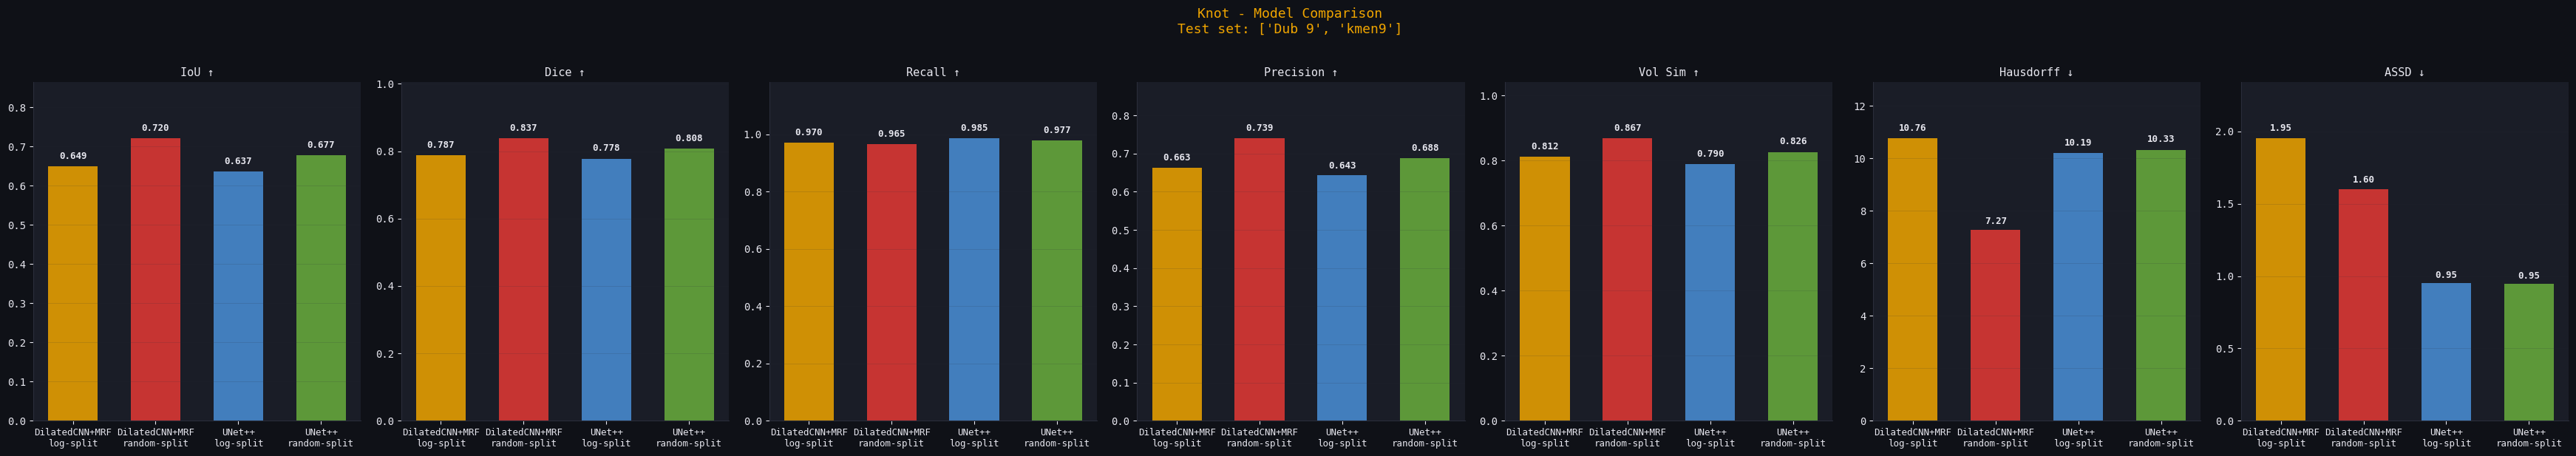

Saved → ./outputs/evaluation\comparison_crack.png


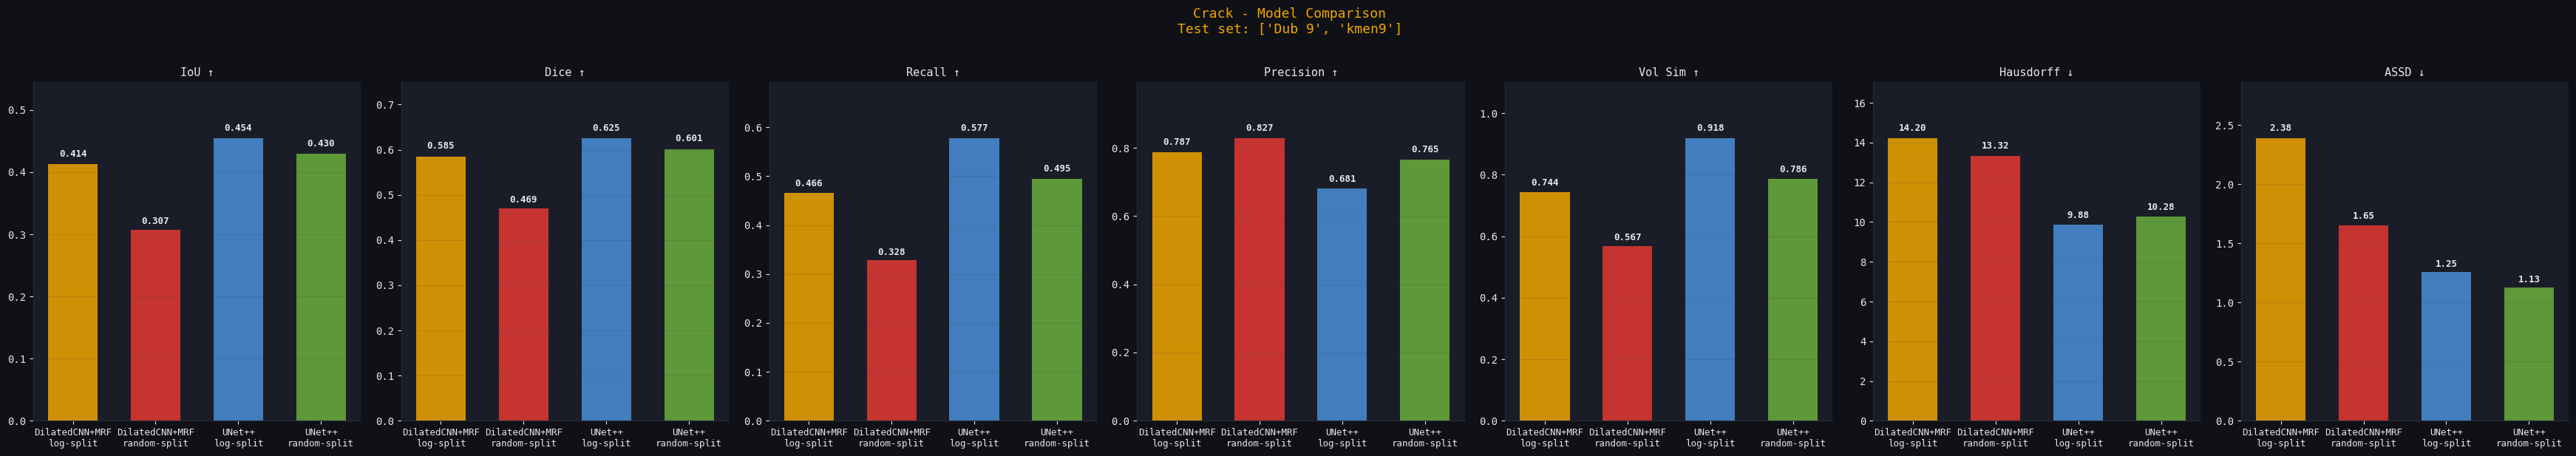

Saved → ./outputs/evaluation\comparison_defect.png


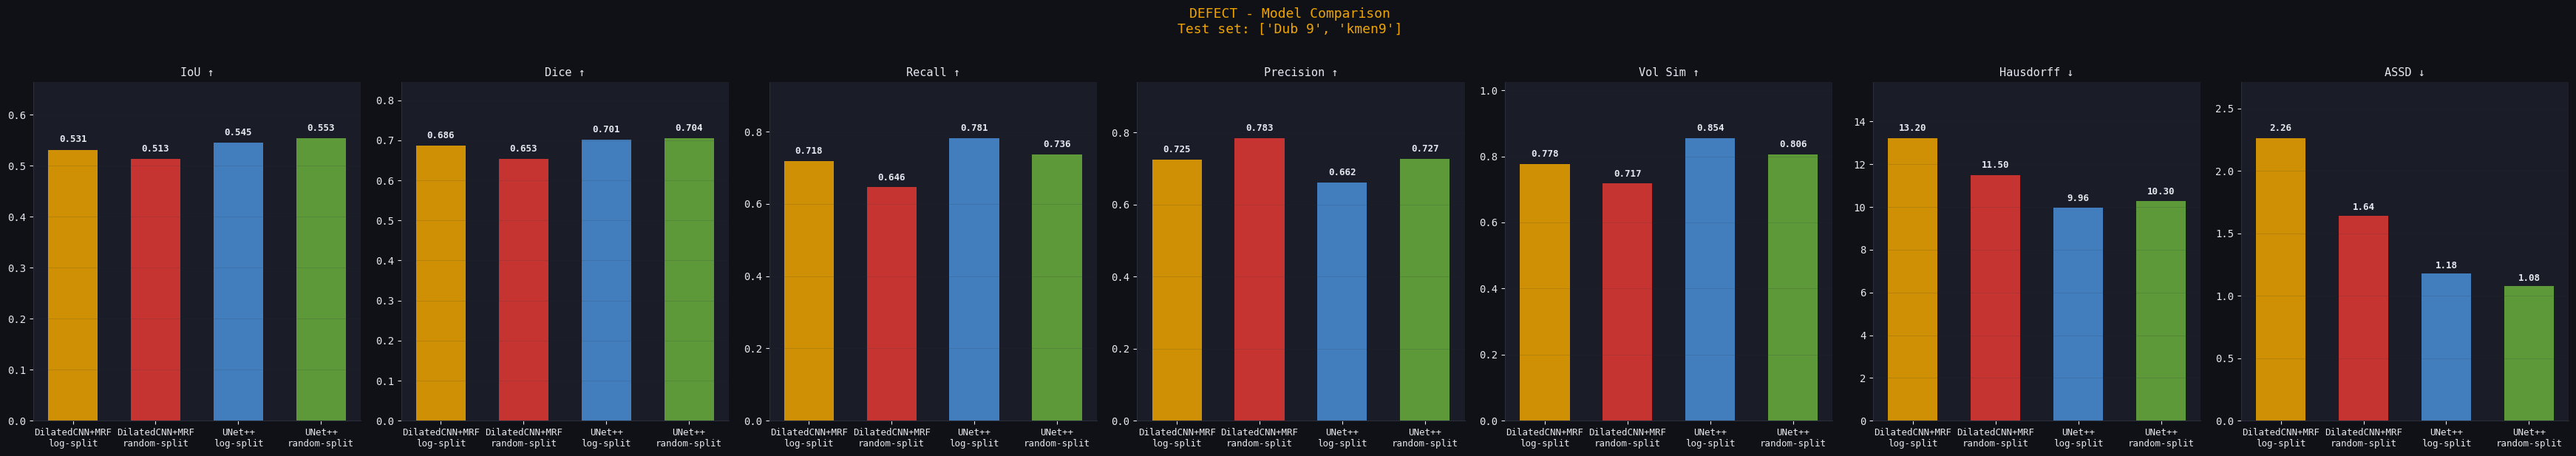

In [11]:
from IPython.display import display
 
PLOT_CLASSES  = ["Knot", "Crack", "DEFECT"]
METRIC_LABELS = {
    "iou": "IoU ↑", "dice": "Dice ↑", "recall": "Recall ↑",
    "precision": "Precision ↑", "vs": "Vol Sim ↑",
    "hd": "Hausdorff ↓", "assd": "ASSD ↓",
}
COLORS = ["#F0A500", "#E53935", "#4A90D9", "#6AAF3D",
          "#9B59B6", "#1ABC9C", "#E67E22"]
 
model_names = list(all_dfs.keys())
n_models    = len(model_names)
 
for cls in PLOT_CLASSES:
    fig, axes = plt.subplots(
        1, len(METRICS),
        figsize=(5 * len(METRICS), 6),
        facecolor=DARK_BG
    )
    sub = summary_df[summary_df["class"] == cls]
 
    for col, metric in enumerate(METRICS):
        ax   = axes[col]
        vals = [
            float(sub[sub["model"] == m][metric].values[0])
            if len(sub[sub["model"] == m]) > 0 else float("nan")
            for m in model_names
        ]
        bars = ax.bar(range(n_models), vals,
                      color=COLORS[:n_models], alpha=0.85, width=0.6)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                label = f"{val:.2f}" if metric in ["hd", "assd"] else f"{val:.3f}"
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 1.02,
                        label, ha="center", va="bottom",
                        fontsize=9, color=TEXT_COL, fontweight="bold")
        ax.set_xticks(range(n_models))
        ax.set_xticklabels(
            [m.replace(" ", "\n") for m in model_names],
            fontsize=9
        )
        ax.set_title(METRIC_LABELS[metric], fontsize=11, pad=6)
        ax.grid(alpha=0.2, axis="y")
        ax.set_ylim(0, max(v for v in vals if not np.isnan(v)) * 1.2
                    if any(not np.isnan(v) for v in vals) else 1)
 
    fig.suptitle(
        f"{cls} - Model Comparison\nTest set: {COMMON_TEST_LOGS}",
        fontsize=13, color=ACCENT, y=1.02
    )
    plt.tight_layout()
    save_path = os.path.join(OUT_DIR, f"comparison_{cls.lower()}.png")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {save_path}")
    display(fig)
    plt.close(fig)

Test logs: ['Dub 9', 'kmen9']
  Dub 9: slice #2 (cache idx 32) - 534 defect pixels
  kmen9: slice #5 (cache idx 122) - 207 defect pixels

Generating predictions: DilatedCNN+MRF log-split

Generating predictions: DilatedCNN+MRF random-split

Generating predictions: UNet++ log-split
  UNet++ encoder: 216/216 ImageNet weights loaded

Generating predictions: UNet++ random-split
  UNet++ encoder: 216/216 ImageNet weights loaded
Saved → ./outputs/evaluation\visual_comparison.png


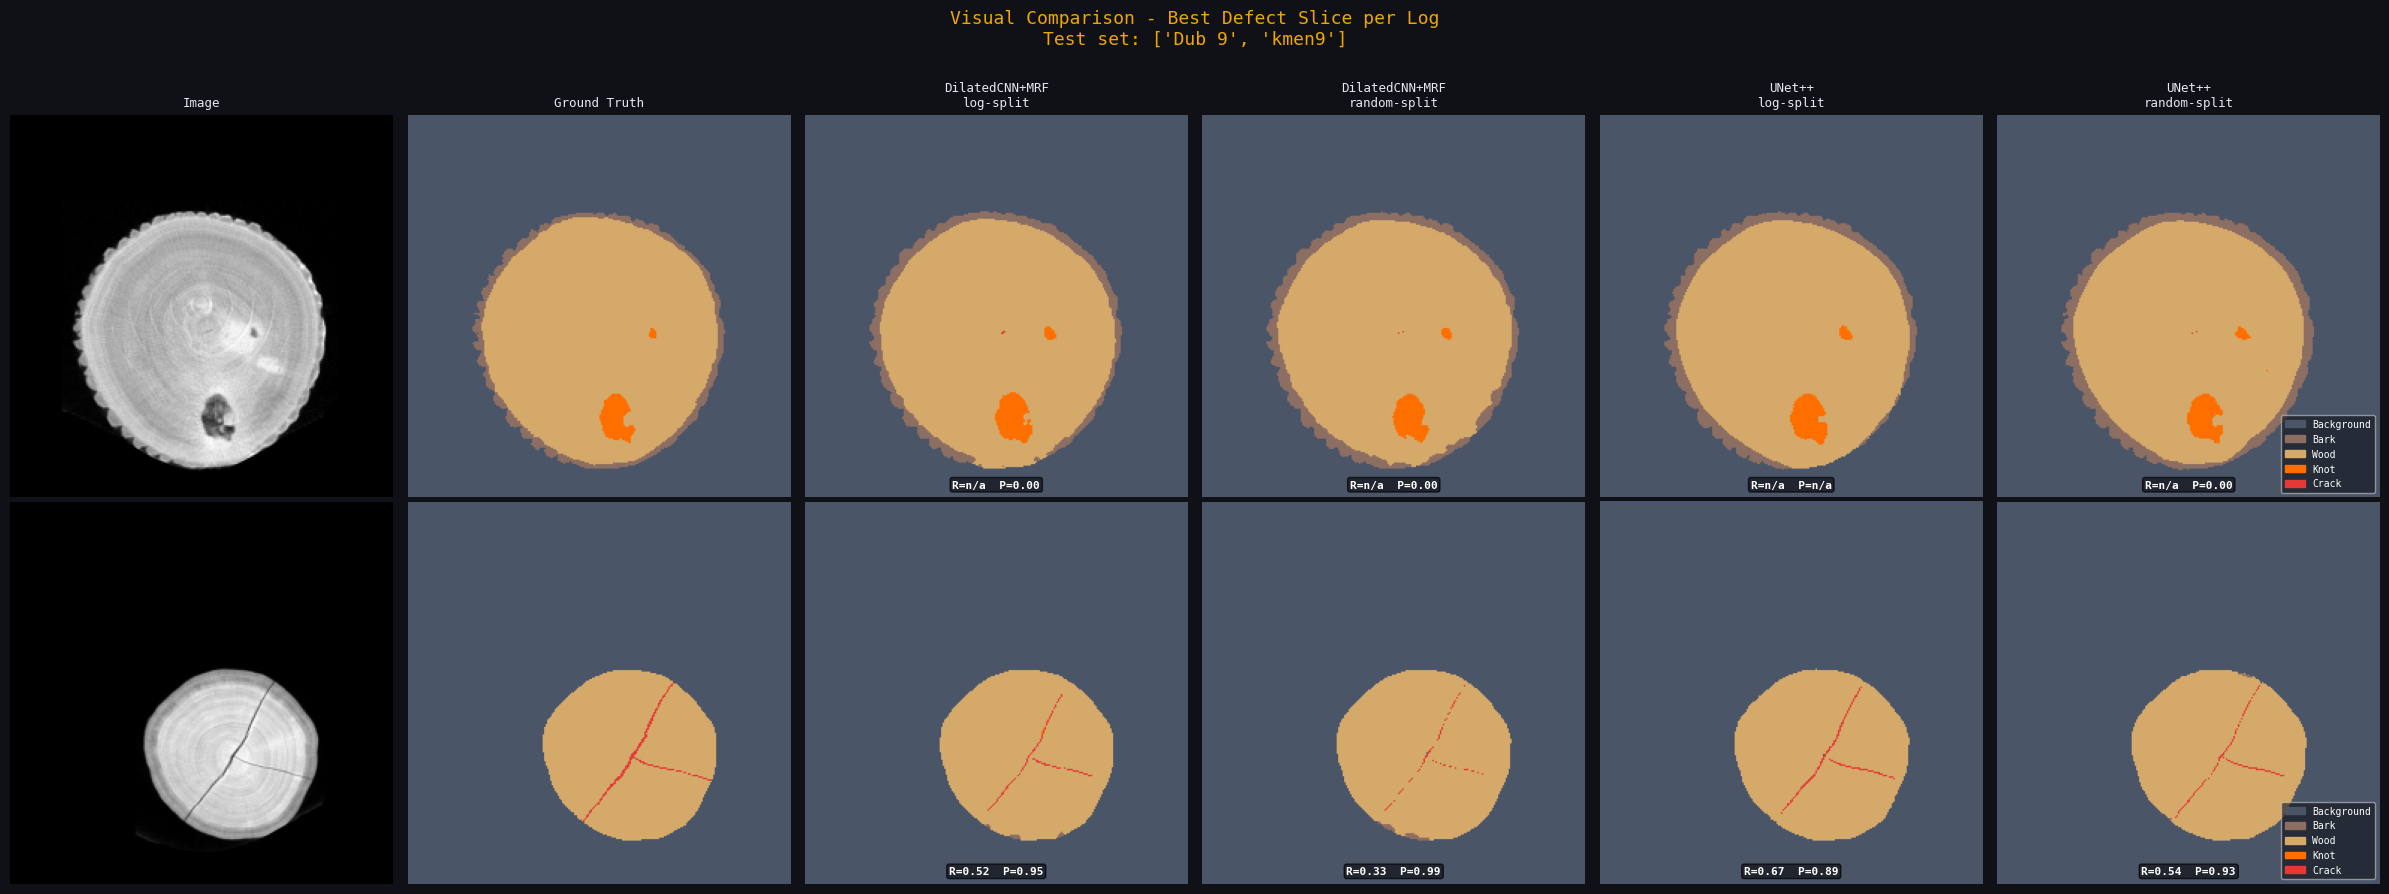

In [12]:
from matplotlib.patches import Patch
 
CLASS_COLORS = {
    0: "#4A5568",   # Background
    1: "#8D6E63",   # Bark
    2: "#D4A96A",   # Wood
    3: "#FF6F00",   # Knot
    4: "#E53935",   # Crack
}
 
def colorise_mask(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.float32)
    for c, hx in CLASS_COLORS.items():
        r, g, b = [int(hx[i:i+2], 16) / 255 for i in (1, 3, 5)]
        rgb[mask_np == c] = [r, g, b]
    return rgb
 
 
# manually selected slices per log
# 0-based index within that log's sorted slices
SLICE_SELECTION = {
    "Dub 9": 2,
    "kmen9": 5, 
}

def get_slice_idx(log_id, slice_number):
    """
    Return index into cached_test for the Nth slice of a given log,
    sorted by defect pixel count descending
    """
    candidates = [
        i for i in range(len(test_pairs))
        if get_log_id(test_pairs[i][0]) == log_id
    ]
    if not candidates:
        return None

    # sort by crack pixels for kmen9, knot pixels for Dub 9
    if "kmen" in log_id.lower():
        candidates.sort(
            key=lambda i: int((np.load(cached_test[i][1]) == 4).sum()),
            reverse=True
        )
    else:
        candidates.sort(
            key=lambda i: int((np.load(cached_test[i][1]) == 3).sum()),
            reverse=True
        )

    if slice_number >= len(candidates):
        print(f"  Warning: {log_id} has only {len(candidates)} slices, "
              f"requested {slice_number}, using last")
        return candidates[-1]
    return candidates[slice_number]
 
 
# collect selected slice per log
test_logs    = sorted(set(get_log_id(p[0]) for p in test_pairs))
best_indices = {
    lg: get_slice_idx(lg, SLICE_SELECTION.get(lg, 0))
    for lg in test_logs
}
print(f"Test logs: {test_logs}")
for lg, idx in best_indices.items():
    if idx is not None:
        mask   = np.load(cached_test[idx][1])
        n_def  = int(np.isin(mask, [3, 4]).sum())
        sl_num = SLICE_SELECTION.get(lg, 0)
        print(f"  {lg}: slice #{sl_num} (cache idx {idx}) - {n_def} defect pixels")
 
# build predictions for each model × each selected slice
model_preds = {}   # {model_name: {log_id: pred_np}}
 
for model_name, model_cfg in MODELS.items():
    if not os.path.exists(model_cfg["path"]):
        continue
    print(f"\nGenerating predictions: {model_name}")
    mdl     = load_checkpoint(model_cfg)
    use_mrf = model_cfg["mrf"]
    beta    = model_cfg.get("mrf_beta", 0.8)
    model_preds[model_name] = {}
 
    for lg, idx in best_indices.items():
        if idx is None:
            continue
        model_preds[model_name][lg] = predict_single(
            mdl, cached_test[idx][0], use_mrf=use_mrf, beta=beta
        )
 
    del mdl
    torch.cuda.empty_cache()
 
# plot
evaluated_models = list(model_preds.keys())
n_models  = len(evaluated_models)
n_logs    = len(test_logs)
 
# cols: Image | GT | model1 | model2 | ...
n_cols = 2 + n_models
fig, axes = plt.subplots(
    n_logs, n_cols,
    figsize=(4 * n_cols, 4.5 * n_logs),
    facecolor=DARK_BG
)
 
# ensure 2D axes array even for single log
if n_logs == 1:
    axes = [axes]
 
legend_patches = [
    Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
    for c in range(NUM_CLASSES)
]
 
for row, lg in enumerate(test_logs):
    idx = best_indices[lg]
    if idx is None:
        for col in range(n_cols):
            axes[row][col].axis("off")
        continue
 
    img_np  = np.load(cached_test[idx][0])[0]   # (H, W)
    mask_np = np.load(cached_test[idx][1])
    n_defect = int(np.isin(mask_np, [3, 4]).sum())
 
    # row label
    axes[row][0].set_ylabel(
        f"{lg}\n({n_defect} defect px)",
        fontsize=8, color=TEXT_COL,
        rotation=0, labelpad=70, va="center"
    )
 
    # image - add column header on first row
    axes[row][0].imshow(img_np, cmap="gray")
    if row == 0:
        axes[row][0].set_title("Image", fontsize=9, pad=6, color=TEXT_COL)
    axes[row][0].axis("off")
 
    # ground truth
    axes[row][1].imshow(colorise_mask(mask_np))
    if row == 0:
        axes[row][1].set_title("Ground Truth", fontsize=9, pad=6, color=TEXT_COL)
    axes[row][1].axis("off")
 
    # model predictions
    for col, model_name in enumerate(evaluated_models):
        ax   = axes[row][2 + col]
        pred = model_preds[model_name].get(lg)
        if pred is None:
            ax.axis("off")
            continue
 
        gt_crack   = int((mask_np == 4).sum())
        pred_crack = int((pred    == 4).sum())
        tp_crack   = int(((mask_np == 4) & (pred == 4)).sum())
        recall_str = f"R={tp_crack/gt_crack:.2f}" if gt_crack > 0 else "R=n/a"
        prec_str   = f"P={tp_crack/pred_crack:.2f}" if pred_crack > 0 else "P=n/a"
 
        ax.imshow(colorise_mask(pred))
 
        # model name as column header only on first row
        if row == 0:
            ax.set_title(
                model_name.replace(" ", "\n"),
                fontsize=9, pad=6, color=TEXT_COL
            )
 
        # R/P stats as text overlay inside the image - never overwrites header
        ax.text(
            0.5, 0.02, f"{recall_str}  {prec_str}",
            transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8,
            color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#0F1117", alpha=0.7)
        )
        ax.axis("off")
 
    # legend on last column of each row
    axes[row][-1].legend(
        handles=legend_patches, fontsize=7,
        loc="lower right", framealpha=0.6,
        facecolor=DARK_BG, labelcolor="white"
    )
 
fig.suptitle(
    f"Visual Comparison - Best Defect Slice per Log\nTest set: {COMMON_TEST_LOGS}",
    fontsize=13, color=ACCENT, y=1.01
)
plt.tight_layout()
save_path = os.path.join(OUT_DIR, "visual_comparison.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved → {save_path}")
display(fig)
plt.close(fig)

## Final model comparison

---

### Visual comparison 

**Dub 9 - knot-dominant slice**
- Ground truth shows two knot regions, no crack annotations
- All models detect the large knot correctly in shape and position
- DilatedCNN log-split and UNet++ random-split show slight over-prediction
  around the knot boundary - the amber region bleeds slightly beyond GT
- UNet++ log-split shows R=n/a P=n/a because this slice has zero crack
  GT pixels and zero crack predictions - the cleanest result
- DilatedCNN random-split and UNet++ random-split both show small false
  positive crack pixels (R=n/a P=0.00) - the model hallucinates hairline
  cracks near the knot boundary on a clean image

**kmen9 - crack-dominant slice**
- Ground truth shows 3 clear radial crack channels from near the centre
- DilatedCNN log-split (R=0.52 P=0.95) - finds roughly half the crack
  area with very high precision. The main channels are detected but tip
  extension is short. Predictions are thin but accurate where they exist
- DilatedCNN random-split (R=0.33 P=0.99) - lowest recall, highest
  precision. Very conservative - only predicts crack where it is
  extremely confident. Misses the finer crack branches entirely
- UNet++ log-split (R=0.67 P=0.89) - best recall, good precision.
  Predicts the widest crack channels closest to GT width. The bottom
  radial crack is detected more completely than any other model
- UNet++ random-split (R=0.54 P=0.93) - middle ground. Better recall
  than DilatedCNN but thinner predictions than UNet++ log-split

---

### Metric table interpretation (corrected aggregation)

**Background / Wood** - all models near-perfect, no meaningful differences

**Bark**
- DilatedCNN log-split best IoU (0.696) and precision (0.735) - MRF
  smoothing helps clean up the irregular bark boundary
- UNet++ models have higher recall (0.965-0.974) but lower precision -
  they over-predict bark area slightly
- HD gap is large: DilatedCNN log-split 27.80px vs UNet++ log-split
  9.05px - UNet++'s skip connections produce much tighter bark boundaries
  despite lower IoU, suggesting the IoU gap is driven by over-prediction
  rather than mislocalisation

**Knot**
- DilatedCNN random-split best IoU (0.720) and best HD (7.27) - the
  random split gave the model more knot variety during training
- All models achieve recall ~0.96-0.98 - knots are found reliably by
  every model
- Precision gap: DilatedCNN random-split 0.739 vs UNet++ log-split 0.643
  - UNet++ over-predicts knot area more than DilatedCNN
- ASSD identical for both UNet++ variants (0.95px) regardless of split -
  the architecture determines boundary quality, not the split strategy

**Crack - the primary differentiator**

| Model | IoU | Recall | Precision | VS | HD | ASSD |
|---|---|---|---|---|---|---|
| DilatedCNN log-split | 0.414 | 0.466 | 0.787 | 0.744 | 14.20 | 2.38 |
| DilatedCNN random-split | 0.307 | 0.328 | 0.827 | 0.568 | 13.32 | 1.65 |
| UNet++ log-split | **0.454** | **0.577** | 0.681 | **0.918** | **9.88** | **1.25** |
| UNet++ random-split | 0.430 | 0.495 | 0.765 | 0.786 | 10.28 | 1.13 |

- UNet++ log-split wins on IoU, Recall, VS, HD and ASSD simultaneously
- VS of 0.918 for UNet++ log-split confirms it predicts closest to the
  correct crack volume - the thinning problem is substantially solved
  compared to DilatedCNN (VS 0.568-0.744)
- DilatedCNN models have much higher precision (0.787-0.827) - they are
  conservative predictors. When they say crack, they are almost always
  right. But they miss a lot.
- The HD gap (9.88 vs 14.20px) directly confirms UNet++ extends crack
  tip predictions closer to the annotated endpoints - the main failure
  mode identified in visualisations is reduced by ~4px worst-case

**DEFECT aggregate**
- UNet++ random-split best overall IoU (0.554) and Dice (0.704)
- UNet++ log-split best recall (0.781) and VS (0.854) and HD (9.96)
- DilatedCNN models have better precision but are outperformed on every
  other defect metric by UNet++ variants
- ASSD: UNet++ log-split 1.18px vs DilatedCNN log-split 2.26px - UNet++
  predictions are on average ~1px closer to GT boundaries

---

### Final evaluation

**Best overall model: UNet++ log-split**
Wins on crack recall (0.577), crack VS (0.918), crack HD (9.88),
defect recall (0.781), and defect ASSD (1.18). The log-stratified
val split during training produced a more crack-aware model than the
random split, at the cost of slightly lower knot IoU.

**Best precision-oriented model: DilatedCNN random-split**
If false positives are the primary concern - e.g. a system where
human operators verify every flagged region - DilatedCNN random-split's
crack precision of 0.827 and knot IoU of 0.720 make it the most
trustworthy predictor when it does fire, despite lower recall.

**Tradeoff**
UNet++ finds more defects (higher recall) but flags more clean pixels
as defective (lower precision). DilatedCNN misses more defects (lower
recall) but raises fewer false alarms (higher precision).